# Clustering -  Tipo de metastasisis

* Ines Gonzales
* Jose Arenas
* Jhonier Correa

# Librerias

In [1]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)

# Lectura de datos y correccion de tipos

In [2]:
# Se cargan los datos
data = pd.read_csv("datos\dataset-tipodemetastasis-limpieza-weka.csv") #Cargar datos en excel
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\jhoni\AppData\Local\Temp\ipykernel_32916\3494474891.py:2: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv("datos\dataset-tipodemetastasis-limpieza-weka.csv") #Cargar datos en excel


,patient_race,payer_type,patient_age,breast_cancer_diagnosis_code,Region,population,density,age_median,age_under_10,age_10_to_19,age_20s,age_30s,age_40s,age_50s,age_60s,age_70s,age_over_80,male,female,married,divorced,never_married,widowed,family_size,family_dual_income,income_household_median,income_household_under_5,income_household_5_to_10,income_household_10_to_15,income_household_15_to_20,income_household_20_to_25,income_household_25_to_35,income_household_35_to_50,income_household_50_to_75,income_household_75_to_100,income_household_100_to_150,income_household_150_over,income_household_six_figure,income_individual_median,home_ownership,housing_units,home_value,rent_median,rent_burden,education_less_highschool,education_highschool,education_some_college,education_bachelors,education_graduate,education_college_or_above,education_stem_degree,labor_force_participation,unemployment_rate,self_employed,farmer,race_white,race_black,race_asian,race_native,race_pacific,race_other,race_multiple,hispanic,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,tipo_metastasis
0,White,COMMERCIAL,62,C50.2_C50.4,West,39121.878790,2295.939394,38.200000,11.878788,13.354545,14.230303,13.418182,13.333333,14.060606,10.248485,5.951515,3.503030,49.893939,50.106061,50.245455,9.827273,35.290909,4.651515,3.622727,61.736364,102741.63640,2.327273,1.536364,2.648485,2.178788,2.409091,5.163636,7.972727,13.936364,12.469697,19.760606,29.596970,49.357576,41287.27273,61.463636,11725.666670,6.776885e+05,2003.125000,34.753125,14.230303,19.987879,29.796970,23.739394,12.245455,35.984848,47.918182,65.230303,5.103030,15.224242,0.027273,54.030303,2.527273,20.827273,0.587879,0.300000,11.645455,10.081818,37.948485,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,Linfatico
1,White,COMMERCIAL,43,C50.1,South,21996.683330,626.236667,37.906667,13.028333,14.463333,12.531667,13.545000,12.860000,12.770000,11.426667,6.565000,2.811667,50.123333,49.876667,55.753333,12.330000,27.195000,4.710000,3.260667,55.801667,85984.74138,2.483333,1.305000,2.716667,2.938333,2.766667,6.763333,12.061667,15.835000,13.560000,20.875000,18.680000,39.555000,40399.03333,72.745000,7786.583333,2.377131e+05,1235.907407,29.358491,10.811667,27.038333,32.368333,19.678333,10.115000,29.793333,37.308475,66.428333,4.560000,13.722034,3.650847,75.820000,9.231667,3.618333,0.463333,0.146667,3.816667,6.898333,19.370000,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,Linfatico
2,White,COMMERCIAL,45,C50.2_C50.4,West,32795.325580,1896.220930,42.871429,10.071429,12.135714,12.538095,12.464286,12.650000,14.847619,12.280952,8.216667,4.759524,49.066667,50.933333,52.604762,11.623810,31.142857,4.623810,3.098095,54.564286,120533.83330,3.435714,1.273810,2.180952,2.211905,2.100000,4.380952,5.885714,10.897619,10.721429,18.850000,38.057143,56.907143,55336.28571,59.221429,12171.302330,1.012474e+06,2354.738095,32.030952,5.835714,12.145238,26.269048,33.285714,22.459524,55.745238,48.938095,64.430952,5.264286,18.502381,0.052381,65.014286,1.438095,18.845238,0.430952,0.252381,5.428571,8.611905,16.716667,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,Linfatico
3,White,'MEDICARE ADVANTAGE',66,C50.9_C79.81,Northeast,5643.771429,219.362857,45.180000,8.511429,14.857143,11.088571,9.754286,13.614286,13.374286,15.685714,9.445714,3.645714,50.911429,49.091429,51.322857,11.760000,30.831429,6.091429,2.908788,54.772727,71005.10000,1.505882,1.091176,3.588235,3.376471,4.079412,7.152941,11.897059,21.908824,14.500000,19.488235,11.400000,30.888235,35780.84375,83.873529,2368.942857,1.504388e+05,794.625000,26.647059,8.300000,36.882857,29.068571,15.874286,9.865714,25.740000,43.081250,60.934286,3.882857,7.070968,1.645161,93.528571,1.031429,0.422857,0.742857,0.002857,1.000000,3.262857,2.465714,13.717143,8.888235,0.638235,25.000000,4.797143,7.745714,40.107248,6.181812,13.562528,VisceralSistemico
4,White,COMMERCIAL,60,C

In [3]:
#Se revisan los tipos de datos (númericos/categoricos)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9412 entries, 0 to 9411
Data columns (total 73 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_race                  9412 non-null   str    
 1   payer_type                    9412 non-null   str    
 2   patient_age                   9412 non-null   int64  
 3   breast_cancer_diagnosis_code  9412 non-null   str    
 4   Region                        9412 non-null   str    
 5   population                    9412 non-null   float64
 6   density                       9412 non-null   float64
 7   age_median                    9412 non-null   float64
 8   age_under_10                  9412 non-null   float64
 9   age_10_to_19                  9412 non-null   float64
 10  age_20s                       9412 non-null   float64
 11  age_30s                       9412 non-null   float64
 12  age_40s                       9412 non-null   float64
 13  age_50s       

In [4]:
# Correción de tipo de datos
for i in data.columns:
  if data[i].dtype=='str':
    data[i]=data[i].astype('category')

In [5]:
# Para verificar el tipo de datos
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9412 entries, 0 to 9411
Data columns (total 73 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   patient_race                  9412 non-null   category
 1   payer_type                    9412 non-null   category
 2   patient_age                   9412 non-null   int64   
 3   breast_cancer_diagnosis_code  9412 non-null   category
 4   Region                        9412 non-null   category
 5   population                    9412 non-null   float64 
 6   density                       9412 non-null   float64 
 7   age_median                    9412 non-null   float64 
 8   age_under_10                  9412 non-null   float64 
 9   age_10_to_19                  9412 non-null   float64 
 10  age_20s                       9412 non-null   float64 
 11  age_30s                       9412 non-null   float64 
 12  age_40s                       9412 non-null   float64 
 13 

In [6]:
data.columns

Index(['patient_race', 'payer_type', 'patient_age',
       'breast_cancer_diagnosis_code', 'Region', 'population', 'density',
       'age_median', 'age_under_10', 'age_10_to_19', 'age_20s', 'age_30s',
       'age_40s', 'age_50s', 'age_60s', 'age_70s', 'age_over_80', 'male',
       'female', 'married', 'divorced', 'never_married', 'widowed',
       'family_size', 'family_dual_income', 'income_household_median',
       'income_household_under_5', 'income_household_5_to_10',
       'income_household_10_to_15', 'income_household_15_to_20',
       'income_household_20_to_25', 'income_household_25_to_35',
       'income_household_35_to_50', 'income_household_50_to_75',
       'income_household_75_to_100', 'income_household_100_to_150',
       'income_household_150_over', 'income_household_six_figure',
       'income_individual_median', 'home_ownership', 'housing_units',
       'home_value', 'rent_median', 'rent_burden', 'education_less_highschool',
       'education_highschool', 'education_s

# Seleccionando variables para la agrupacion

In [7]:
variables_a_conservar = ['patient_race', 'payer_type', 'patient_age','income_household_median','rent_median', 'health_uninsured']

In [8]:
# Copia de los datos
df=data.copy()

# DF solo con las variables de interes
df = df[variables_a_conservar]
df.head()

,patient_race,payer_type,patient_age,income_household_median,rent_median,health_uninsured
0,White,COMMERCIAL,62,102741.63640,2003.125000,7.018182
1,White,COMMERCIAL,43,85984.74138,1235.907407,15.066667
2,White,COMMERCIAL,45,120533.83330,2354.738095,4.404762
3,White,'MEDICARE ADVANTAGE',66,71005.10000,794.625000,4.797143
4,White,COMMERCIAL,60,60431.16667,711.259259,8.753333


# Preparaciones
* Transformaciones: normalizar y crear dummies

In [9]:
# Normalizar

# Variables categoricas
variables_cat = ['patient_race', 'payer_type']
variables_a_normalizar = [col for col in df.columns if col not in variables_cat]

min_max_scaler = MinMaxScaler()
min_max_scaler.fit(df[variables_a_normalizar])
df[variables_a_normalizar] = min_max_scaler.transform(df[variables_a_normalizar])
df.head()


,patient_race,payer_type,patient_age,income_household_median,rent_median,health_uninsured
0,White,COMMERCIAL,0.602740,0.532126,0.617727,0.182208
1,White,COMMERCIAL,0.342466,0.404390,0.312894,0.502532
2,White,COMMERCIAL,0.369863,0.667754,0.757430,0.078196
3,White,'MEDICARE ADVANTAGE',0.657534,0.290201,0.137563,0.093813
4,White,COMMERCIAL,0.575342,0.209597,0.104440,0.251266


In [10]:
# Se crean dummies para las variables categoricas
df = pd.get_dummies(df, columns=variables_cat, drop_first=False, dtype=int)
df.head()

,patient_age,income_household_median,rent_median,health_uninsured,patient_race_Asian,patient_race_Black,patient_race_Hispanic,patient_race_Other,patient_race_White,payer_type_'MEDICARE ADVANTAGE',payer_type_COMMERCIAL,payer_type_MEDICAID
0,0.602740,0.532126,0.617727,0.182208,0,0,0,0,1,0,1,0
1,0.342466,0.404390,0.312894,0.502532,0,0,0,0,1,0,1,0
2,0.369863,0.667754,0.757430,0.078196,0,0,0,0,1,0,1,0
3,0.657534,0.290201,0.137563,0.093813,0,0,0,0,1,1,0,0
4,0.575342,0.209597,0.104440,0.251266,0,0,0,0,1,0,1,0


# 2. Aprendizaje del Modelo
* Metodo del codo
* Aplicar kmeans

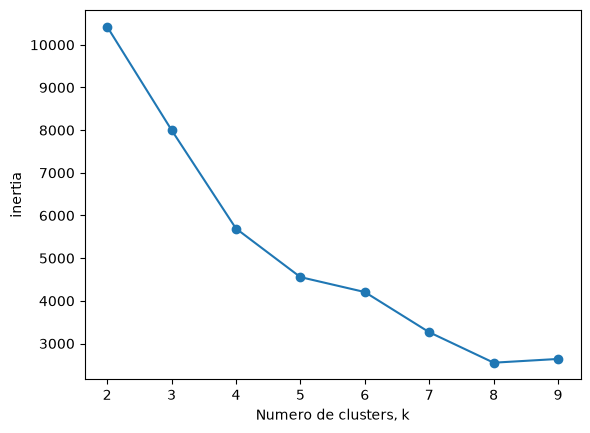

In [11]:
#Método del codo para encontrar la mejor cantidad de clusters: inertia
from sklearn.cluster import KMeans

ks = range(2, 10) # crear valores del 2 al 20
inertias = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k,max_iter=300)
    model.fit(df)
    inertias.append(model.inertia_)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

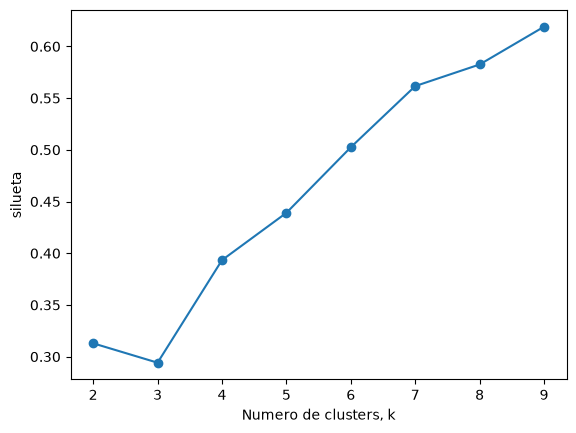

In [12]:
#Método de la rodilla: silueta
from sklearn import metrics

ks = range(2, 10) # crear valores del 2 al 20
siluetas = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k,max_iter=800)
    model.fit(df)
    sil=metrics.silhouette_score(df, model.labels_)
    siluetas.append(sil)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, siluetas, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('silueta')
plt.xticks(ks)
plt.show()

In [13]:
#Creación de modelo de clustering con Kmeans
from sklearn.cluster import KMeans
k=4
model = KMeans(n_clusters=k, max_iter=300)
model.fit(df) #100% datos

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 12)"

# 3. Evaluación del Modelo


*   Inertia: valor pequeño esperado
*   Silueta: valor positivo esperado, idealmente mayor a 0.5



In [14]:
#Evaluación
from sklearn import metrics

#Inertia: se require valor pequeño
print('Inercia o cohesión:', model.inertia_)

#Silueta: se requiere que sea positivo, ideal 0.5-1.0
sil=metrics.silhouette_score(df, model.labels_)
print('Silueta:',sil)

Inercia o cohesión: 6765.509989935504
Silueta: 0.3640961569612027


# 4. Perfilamiento

Descripción de centroides

In [15]:
# Desnormalizar
# Se realiza una des-normalización centroides
centroides=pd.DataFrame(model.cluster_centers_, columns=df.columns.values)
centroides.round(1).abs()
centroides[variables_a_normalizar]=min_max_scaler.inverse_transform(centroides[variables_a_normalizar])
centroides.round(0)

,patient_age,income_household_median,rent_median,health_uninsured,patient_race_Asian,patient_race_Black,patient_race_Hispanic,patient_race_Other,patient_race_White,payer_type_'MEDICARE ADVANTAGE',payer_type_COMMERCIAL,payer_type_MEDICAID
0,55.0,76711.0,1485.0,10.0,0.0,0.0,1.0,-0.0,-0.0,0.0,0.0,1.0
1,66.0,73839.0,1178.0,8.0,-0.0,0.0,-0.0,0.0,1.0,1.0,0.0,-0.0
2,58.0,73525.0,1322.0,9.0,0.0,1.0,-0.0,0.0,-0.0,0.0,0.0,1.0
3,57.0,71612.0,1177.0,8.0,-0.0,0.0,0.0,0.0,1.0,-0.0,0.0,1.0


**DESCRIPCIÓN DE PERFILES**

PERFIL 0: Salario de 4.800.000, no hijos, incapacidades 7 dias al año, 15 años de antiguedad, casados, no carro, no casa...

PERFIL 1:

PERFIL 2:

PERFIL 3:

PERFIL 4:

PERFIL 5:

PERFIL 6:

PERFIL 7:

